# Listwise Reranking on Snippets (RankZephyr 7B V1 Full)

This notebook:
1. Loads top-k docs from `rerank/post_rerank_fusion_snippet/runs` and top-1 snippet per doc from `snippet/snippet_rerank/windows`
2. Plots a token-length histogram to help choose k (number of docs/snippets for listwise reranking)
3. Runs a listwise reranker (RankLLM + RankZephyr 7B V1 Full) on the snippets
4. Evaluates MAP@10 and compares with the baseline per split

## 1) Setup and Paths

In [ ]:
from __future__ import annotations

import os

# Keep plotting headless-friendly and avoid known vLLM/tokenizers multiprocessing issues.
os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
# vLLM 0.11.0 enables V1 multiprocessing by default; disable it here because
# this notebook-style script executes top-level code and is not structured around
# a __main__ guard / spawn-safe entrypoint.
os.environ.setdefault("VLLM_ENABLE_V1_MULTIPROCESSING", "0")
# If multiprocessing is enabled later, prefer spawn over fork for CUDA safety.
os.environ.setdefault("VLLM_WORKER_MULTIPROC_METHOD", "spawn")

import json
import re
from collections import defaultdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [ ]:
# Determine repo root from script location so paths work from any working directory.
# When run as a script: __file__ is defined.
# When run in a notebook: fall back to cwd-based ".." (notebook is in notebooks/).
try:
    _SCRIPT_DIR = Path(__file__).resolve().parent  # notebooks/
    _REPO_ROOT = _SCRIPT_DIR.parent
except NameError:
    _REPO_ROOT = Path("..").resolve()

import sys
sys.path.insert(0, str(_REPO_ROOT / "scripts" / "public" / "shared_scripts"))

from retrieval_eval.common import (
    build_topics_and_gold,
    evaluate_run,
    load_questions,
    normalize_pmid,
    run_df_to_run_map,
)

In [ ]:
WORKFLOW_OUTPUT = _REPO_ROOT / "output" / "workflow_baseline_full_run_both_routes_gemma"
POST_RERANK_FUSION_SNIPPET_RUNS = WORKFLOW_OUTPUT / "rerank/post_rerank_fusion_snippet" / "runs"
SNIPPET_WINDOWS_DIR = WORKFLOW_OUTPUT / "snippet_rerank" / "windows"

# Output root for this listwise experiment (designed for non-interactive HPC runs)
LISTWISE_OUT = WORKFLOW_OUTPUT / "listwise_rankzephyr_test"
FIG_OUT = LISTWISE_OUT / "figures"
# Separate output dirs for single-window vs sliding-window
RUNS_SINGLE = LISTWISE_OUT / "runs_single_window"
RUNS_SLIDING = LISTWISE_OUT / "runs_sliding_window"
LISTWISE_OUT.mkdir(parents=True, exist_ok=True)
FIG_OUT.mkdir(parents=True, exist_ok=True)
RUNS_SINGLE.mkdir(parents=True, exist_ok=True)
RUNS_SLIDING.mkdir(parents=True, exist_ok=True)

# Data paths - can be overridden via environment variables
TRAIN_JSON = Path(os.environ.get(
    "TRAIN_JSON",
    str(_REPO_ROOT / "example" / "training14b_10pct_sample.json")
))
_TEST_JSONS_DIR = Path(os.environ.get(
    "TEST_JSONS_DIR",
    str(_REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched")
))
TEST_JSONS = [
    _TEST_JSONS_DIR / f"13B{i}_golden.json"
    for i in range(1, 5)  # 13B1 to 13B4
]

TOP_K_DOCS = 50  # Load top-50 for sliding window pool
TOP_K_RERANK = 15  # Single-window: top-15 docs, one pass

# Sliding window config
SLIDING_POOL = 50      # Pool of docs to consider
SLIDING_WINDOW = 10    # Window size (docs per pass)
SLIDING_STRIDE = 5     # Step between windows

# Safety: truncate snippets longer than this to guarantee we fit in context.
# Budget: 4096 - 230 (prompt) - 50 (query) - 15*5 (numbering) = 3741 tokens for snippets
# Per snippet: 3741 / 15 ≈ 249 tokens max
MAX_SNIPPET_TOKENS = 250

print("Runtime env:")
print(f"  VLLM_ENABLE_V1_MULTIPROCESSING={os.environ.get('VLLM_ENABLE_V1_MULTIPROCESSING')}")
print(f"  VLLM_WORKER_MULTIPROC_METHOD={os.environ.get('VLLM_WORKER_MULTIPROC_METHOD')}")
print(f"  TOKENIZERS_PARALLELISM={os.environ.get('TOKENIZERS_PARALLELISM')}")
print("Paths configured:")
print(f"  REPO_ROOT:              {_REPO_ROOT}")
print(f"  POST_RERANK_FUSION_SNIPPET_RUNS: {POST_RERANK_FUSION_SNIPPET_RUNS.resolve()}")
print(f"  SNIPPET_WINDOWS_DIR:    {SNIPPET_WINDOWS_DIR.resolve()}")
print(f"  TRAIN_JSON exists:      {TRAIN_JSON.exists()} ({TRAIN_JSON})")
print(f"  TEST_JSONS exist:       {[p.exists() for p in TEST_JSONS]}")

## 2) Helper: Parse split from run stem

In [ ]:
def parse_split_from_run_stem(run_stem: str) -> Optional[str]:
    """
    Extract the split name from a run file stem like:
      best_rrf_13B1_golden_top5000_rrf_poolR200_poolH200_k60
    Returns: 13B1_golden (or None if no match)
    """
    m = re.fullmatch(
        r"best_rrf_(.+)_top\d+(?:_rrf_pool(?:\d+_k\d+|R\d+_poolH\d+_k\d+))?",
        run_stem,
    )
    return m.group(1) if m else None


def load_run_tsv(path: Path) -> pd.DataFrame:
    """Load a run TSV and return DataFrame with qid, docno, rank columns."""
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols.get("qid") or cols.get("query_id") or df.columns[0]
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc") or df.columns[1]
    rank_col = cols.get("rank")

    out = pd.DataFrame({
        "qid": df[qid_col].astype(str),
        "docno": df[doc_col].astype(str).map(normalize_pmid),
    })
    if rank_col:
        out["rank"] = df[rank_col].astype(int)
    else:
        out["rank"] = out.groupby("qid").cumcount() + 1
    return out.sort_values(["qid", "rank"]).reset_index(drop=True)


print("Helpers defined.")

## 3) Load top-k docs per query and top-1 snippet per doc

In [ ]:
def load_windows_jsonl(path: Path) -> Dict[Tuple[str, str], Tuple[str, float]]:
    """
    Load windows JSONL and return (qid, docno) -> (best_window_text, ce_score).
    Keeps only the top-1 window per (qid, docno) by ce_score.
    """
    best: Dict[Tuple[str, str], Tuple[str, float]] = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            qid = str(rec["qid"])
            docno = normalize_pmid(rec["docno"])
            text = rec["window_text"]
            score = float(rec["ce_score"])
            key = (qid, docno)
            if key not in best or score > best[key][1]:
                best[key] = (text, score)
    return best

In [ ]:
run_files = sorted(POST_RERANK_FUSION_SNIPPET_RUNS.glob("*.tsv"))
print(f"Found {len(run_files)} run files in {POST_RERANK_FUSION_SNIPPET_RUNS}")

splits_data: Dict[str, dict] = {}

for run_path in run_files:
    split = parse_split_from_run_stem(run_path.stem)
    if split is None:
        print(f"  Skipping {run_path.name} (could not parse split)")
        continue
    
    windows_path = SNIPPET_WINDOWS_DIR / f"{split}.jsonl"
    if not windows_path.exists():
        print(f"  Skipping {split}: windows file not found at {windows_path}")
        continue
    
    run_df = load_run_tsv(run_path)
    windows = load_windows_jsonl(windows_path)
    
    top_docs_per_query: Dict[str, List[str]] = {}
    for qid, g in run_df.groupby("qid", sort=False):
        top_docs_per_query[str(qid)] = g.head(TOP_K_DOCS)["docno"].tolist()
    
    snippets_per_query: Dict[str, Dict[str, str]] = {}
    for qid, docnos in top_docs_per_query.items():
        snippets_per_query[qid] = {}
        for docno in docnos:
            key = (qid, docno)
            if key in windows:
                snippets_per_query[qid][docno] = windows[key][0]
    
    splits_data[split] = {
        "run_df": run_df,
        "top_docs_per_query": top_docs_per_query,
        "snippets_per_query": snippets_per_query,
        "run_path": run_path,
    }
    n_queries = len(top_docs_per_query)
    n_snippets = sum(len(v) for v in snippets_per_query.values())
    print(f"  Loaded {split}: {n_queries} queries, {n_snippets} snippets (top-{TOP_K_DOCS} docs)")

print(f"\nTotal splits loaded: {len(splits_data)}")

## 4) Tokenizer and histogram of snippet token lengths

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "castorini/rank_zephyr_7b_v1_full"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
RANKZEPHYR_CONTEXT_SIZE = 4096

print(f"Loaded tokenizer for {MODEL_NAME}")
print(f"Using RankZephyr context size: {RANKZEPHYR_CONTEXT_SIZE}")

In [ ]:
all_token_lengths = []
short_snippets: List[dict] = []
SHORT_LEN_THRESHOLD = 5  # investigate very short snippets

for split, data in splits_data.items():
    for qid, doc_snippets in data["snippets_per_query"].items():
        for docno, snippet_text in doc_snippets.items():
            tokens = tokenizer.encode(snippet_text, add_special_tokens=False)
            tlen = len(tokens)
            all_token_lengths.append(tlen)
            if tlen <= SHORT_LEN_THRESHOLD:
                short_snippets.append(
                    {
                        "split": split,
                        "qid": qid,
                        "docno": docno,
                        "token_len": tlen,
                        "snippet": snippet_text,
                    }
                )

print(f"Total snippets across all splits: {len(all_token_lengths)}")
print(f"Token length stats:")
print(f"  Min:    {np.min(all_token_lengths)}")
print(f"  Max:    {np.max(all_token_lengths)}")
print(f"  Mean:   {np.mean(all_token_lengths):.1f}")
print(f"  Median: {np.median(all_token_lengths):.1f}")
print(f"  P90:    {np.percentile(all_token_lengths, 90):.1f}")
print(f"  P95:    {np.percentile(all_token_lengths, 95):.1f}")
print(f"  P99:    {np.percentile(all_token_lengths, 99):.1f}")
print(f"  Very short (<= {SHORT_LEN_THRESHOLD} tokens): {len(short_snippets)}")

if short_snippets:
    print("\nExamples of very short snippets (first 10):")
    for rec in short_snippets[:10]:
        print(
            f"[{rec['split']}] qid={rec['qid']} docno={rec['docno']} "
            f"len={rec['token_len']} snippet={rec['snippet']!r}"
        )
    short_path = LISTWISE_OUT / "short_snippets.jsonl"
    with short_path.open("w", encoding="utf-8") as f:
        for rec in short_snippets:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
    print(f"\nSaved all very short snippets (len <= {SHORT_LEN_THRESHOLD}) to {short_path}")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(all_token_lengths, bins=50, edgecolor="black", alpha=0.7)
ax.axvline(np.mean(all_token_lengths), color="red", linestyle="--", label=f"Mean: {np.mean(all_token_lengths):.1f}")
ax.axvline(np.percentile(all_token_lengths, 95), color="orange", linestyle="--", label=f"P95: {np.percentile(all_token_lengths, 95):.1f}")
ax.set_xlabel("Snippet Token Length")
ax.set_ylabel("Count")
ax.set_title(f"Histogram of Snippet Token Lengths (all splits, n={len(all_token_lengths)})")
ax.legend()
plt.tight_layout()
hist_path = FIG_OUT / "snippet_token_hist.png"
fig.savefig(hist_path, dpi=150)
plt.close(fig)
print(f"Saved snippet token histogram to {hist_path}")

## 5) Choose k and estimate total input token count

In [ ]:
def estimate_query_token_len(tokenizer, query_text: str) -> int:
    return len(tokenizer.encode(query_text, add_special_tokens=False))


all_questions: List[dict] = []
print("\nLoading questions from JSON files:")
if TRAIN_JSON.exists():
    qs = load_questions(TRAIN_JSON)
    all_questions.extend(qs)
    print(f"  TRAIN_JSON: loaded {len(qs)} questions")
else:
    print(f"  TRAIN_JSON: NOT FOUND at {TRAIN_JSON}")

for p in TEST_JSONS:
    if p.exists():
        qs = load_questions(p)
        all_questions.extend(qs)
        print(f"  {p.name}: loaded {len(qs)} questions")
    else:
        print(f"  {p.name}: NOT FOUND at {p}")

qid_to_query: Dict[str, str] = {}
for q in all_questions:
    qid = str(q.get("id") or q.get("qid"))
    query_text = str(q.get("body") or q.get("query") or q.get("question") or "")
    qid_to_query[qid] = query_text

print(f"\nTotal: {len(qid_to_query)} queries loaded from train/test JSONs")
if len(qid_to_query) == 0:
    print("WARNING: No queries loaded! Check that the data/ directory is mounted correctly.")
    print(f"  Expected TRAIN_JSON at: {TRAIN_JSON.resolve()}")
    print(f"  Expected TEST_JSONS at: {[p.resolve() for p in TEST_JSONS]}")

In [ ]:
# Analyze token counts for both single-window and sliding-window scenarios
print(f"Configurations:")
print(f"  Single-window: k={TOP_K_RERANK} docs/snippets")
print(f"  Sliding-window: pool={SLIDING_POOL}, window={SLIDING_WINDOW}, stride={SLIDING_STRIDE}")

# Analyze for single window (k=15) - this is the per-window token count
k_analysis = TOP_K_RERANK  # Window size for both approaches
total_input_tokens_per_query = []

for split, data in splits_data.items():
    for qid, doc_snippets in data["snippets_per_query"].items():
        query_text = qid_to_query.get(qid, "")
        query_tokens = estimate_query_token_len(tokenizer, query_text)
        
        top_k_docnos = data["top_docs_per_query"][qid][:k_analysis]
        snippet_tokens = 0
        for docno in top_k_docnos:
            if docno in doc_snippets:
                snippet_tokens += len(tokenizer.encode(doc_snippets[docno], add_special_tokens=False))
        
        # Rough allowance for RankZephyr listwise prompt formatting / instructions.
        prompt_overhead = 200
        total = query_tokens + snippet_tokens + prompt_overhead
        total_input_tokens_per_query.append(total)

stats_prompt = {
    "window_size": int(k_analysis),
    "single_window_k": int(TOP_K_RERANK),
    "sliding_pool": int(SLIDING_POOL),
    "sliding_window": int(SLIDING_WINDOW),
    "sliding_stride": int(SLIDING_STRIDE),
    "mean": float(np.mean(total_input_tokens_per_query)),
    "median": float(np.median(total_input_tokens_per_query)),
    "p95": float(np.percentile(total_input_tokens_per_query, 95)),
    "max": float(np.max(total_input_tokens_per_query)),
}
context_limit = RANKZEPHYR_CONTEXT_SIZE
over_limit = sum(1 for t in total_input_tokens_per_query if t > context_limit)
stats_prompt["context_limit"] = int(context_limit)
stats_prompt["n_over_limit"] = int(over_limit)
stats_prompt["n_total"] = int(len(total_input_tokens_per_query))

print("Estimated total input tokens per window (query + snippets + prompt overhead):")
for k_stat, v in stats_prompt.items():
    print(f"  {k_stat}: {v}")

prompt_stats_path = LISTWISE_OUT / "prompt_token_stats.json"
prompt_stats_path.write_text(json.dumps(stats_prompt, indent=2), encoding="utf-8")
print(f"Saved prompt token stats to {prompt_stats_path}")

## 6) Listwise Reranker (RankLLM + RankZephyr 7B V1 Full)

RankLLM provides listwise reranking with open-source listwise LLM rerankers.
For RankZephyr, we use the Zephyr-specific reranker path and avoid the generic
`Reranker` import because current RankLLM releases can eagerly import the LiT5
code path, which may conflict with the newer Transformers stack bundled in the
official vLLM image.

In [ ]:
try:
    import inspect

    from rank_llm.data import Request, Candidate, Query
    from rank_llm.rerank.listwise import ZephyrReranker

    RANKLLM_AVAILABLE = True
    print("RankLLM imported successfully")
except ImportError as e:
    print(f"RankLLM not available: {e}")
    print("Install with: pip install rank-llm")
    RANKLLM_AVAILABLE = False


def build_zephyr_reranker(model_name: str, context_size: int = 4096):
    """
    Create a Zephyr reranker while being tolerant to small API changes across
    RankLLM versions. The official docs show `ZephyrReranker()` directly, but we
    try to pass the explicit model name / context size when the constructor
    exposes matching parameters.
    """
    sig = inspect.signature(ZephyrReranker)
    params = sig.parameters

    candidate_kwargs = {}
    if "model" in params:
        candidate_kwargs["model"] = model_name
    elif "model_path" in params:
        candidate_kwargs["model_path"] = model_name

    if "context_size" in params:
        candidate_kwargs["context_size"] = context_size

    attempts = []
    if candidate_kwargs:
        attempts.append(candidate_kwargs)
    attempts.append({})

    last_err = None
    for kwargs in attempts:
        try:
            print(f"Trying ZephyrReranker init with kwargs={kwargs}")
            return ZephyrReranker(**kwargs)
        except TypeError as e:
            last_err = e
            continue

    raise last_err if last_err is not None else RuntimeError("Could not initialize ZephyrReranker")

In [ ]:
if RANKLLM_AVAILABLE:
    print(f"Initializing RankZephyr reranker with model: {MODEL_NAME}")
    reranker = build_zephyr_reranker(MODEL_NAME, context_size=RANKZEPHYR_CONTEXT_SIZE)
    print("Reranker initialized")

In [ ]:
def truncate_snippet(snippet: str, max_tokens: int, tokenizer) -> str:
    """Truncate snippet to max_tokens if it exceeds the limit."""
    tokens = tokenizer.encode(snippet, add_special_tokens=False)
    if len(tokens) <= max_tokens:
        return snippet
    truncated_tokens = tokens[:max_tokens]
    return tokenizer.decode(truncated_tokens, skip_special_tokens=True)


def build_requests_for_split(
    split: str,
    data: dict,
    qid_to_query: Dict[str, str],
    k: int,
    tokenizer,
    max_snippet_tokens: int,
) -> Tuple[List["Request"], List[Tuple[str, List[str]]], int]:
    """
    Build RankLLM Request objects for each query in the split.
    Returns: (list of Request, list of (qid, [docnos in order]), n_truncated)
    """
    requests = []
    qid_docno_order = []
    n_truncated = 0
    
    for qid, top_docnos in data["top_docs_per_query"].items():
        query_text = qid_to_query.get(qid, "")
        if not query_text:
            continue
        
        top_k_docnos = top_docnos[:k]
        doc_snippets = data["snippets_per_query"].get(qid, {})
        
        candidates = []
        valid_docnos = []
        for rank, docno in enumerate(top_k_docnos, start=1):
            if docno in doc_snippets:
                snippet = doc_snippets[docno]
                # Truncate if too long
                orig_len = len(tokenizer.encode(snippet, add_special_tokens=False))
                if orig_len > max_snippet_tokens:
                    snippet = truncate_snippet(snippet, max_snippet_tokens, tokenizer)
                    n_truncated += 1
                candidates.append(Candidate(docid=docno, doc={"text": snippet}, score=0.0))
                valid_docnos.append(docno)
        
        if not candidates:
            continue
        
        query_obj = Query(text=query_text, qid=qid)
        req = Request(query=query_obj, candidates=candidates)
        requests.append(req)
        qid_docno_order.append((qid, valid_docnos))
    
    return requests, qid_docno_order, n_truncated


def rerank_and_build_run(
    reranker,
    requests: List["Request"],
    qid_docno_order: List[Tuple[str, List[str]]],
) -> Dict[str, List[str]]:
    """
    Run the reranker on requests and build run_map[qid] = [docno_1, docno_2, ...].
    Single-window mode: just rerank once.
    """
    if not requests:
        return {}

    results = reranker.rerank_batch(requests=requests, rank_start=0, rank_end=len(requests[0].candidates))
    
    run_map: Dict[str, List[str]] = {}
    for (qid, _original_docnos), result in zip(qid_docno_order, results):
        reranked_docnos = [str(c.docid) for c in result.candidates]
        run_map[qid] = reranked_docnos
    
    return run_map


def rerank_sliding_window(
    reranker,
    requests: List["Request"],
    qid_docno_order: List[Tuple[str, List[str]]],
    window_size: int,
    stride: int,
) -> Dict[str, List[str]]:
    """
    Run the reranker with sliding window and build run_map[qid] = [docno_1, docno_2, ...].
    RankLLM's rerank_batch supports window_size and step parameters.
    """
    if not requests:
        return {}

    # RankLLM sliding window: rank_end = pool size, window_size and step control the sliding
    pool_size = len(requests[0].candidates) if requests else 0
    results = reranker.rerank_batch(
        requests=requests,
        rank_start=0,
        rank_end=pool_size,
        window_size=window_size,
        step=stride,
    )
    
    run_map: Dict[str, List[str]] = {}
    for (qid, _original_docnos), result in zip(qid_docno_order, results):
        reranked_docnos = [str(c.docid) for c in result.candidates]
        run_map[qid] = reranked_docnos
    
    return run_map

In [ ]:
# Run both single-window and sliding-window approaches
single_window_runs: Dict[str, Dict[str, List[str]]] = {}
sliding_window_runs: Dict[str, Dict[str, List[str]]] = {}

# For single-window: use TOP_K_RERANK docs
k_single = TOP_K_RERANK
# For sliding-window: use SLIDING_POOL docs
k_sliding = SLIDING_POOL

total_truncated_single = 0
total_truncated_sliding = 0

if RANKLLM_AVAILABLE:
    for split, data in tqdm(splits_data.items(), desc="Reranking splits"):
        print(f"\n{'='*60}")
        print(f"--- Processing {split} ---")
        
        # === Single-Window Reranking (top-15, one pass) ===
        print(f"\n[Single Window] k={k_single}")
        requests_single, qid_docno_single, n_trunc_single = build_requests_for_split(
            split, data, qid_to_query, k_single, tokenizer, MAX_SNIPPET_TOKENS
        )
        total_truncated_single += n_trunc_single
        print(f"  Built {len(requests_single)} requests ({n_trunc_single} snippets truncated)")
        
        if requests_single:
            run_map = rerank_and_build_run(reranker, requests_single, qid_docno_single)
            single_window_runs[split] = run_map
            print(f"  Reranked {len(run_map)} queries")
        else:
            single_window_runs[split] = {}
            print("  No valid requests")
        
        # === Sliding-Window Reranking (pool=50, window=15, stride=5) ===
        print(f"\n[Sliding Window] pool={k_sliding}, window={SLIDING_WINDOW}, stride={SLIDING_STRIDE}")
        requests_sliding, qid_docno_sliding, n_trunc_sliding = build_requests_for_split(
            split, data, qid_to_query, k_sliding, tokenizer, MAX_SNIPPET_TOKENS
        )
        total_truncated_sliding += n_trunc_sliding
        print(f"  Built {len(requests_sliding)} requests ({n_trunc_sliding} snippets truncated)")
        
        if requests_sliding:
            run_map = rerank_sliding_window(
                reranker, requests_sliding, qid_docno_sliding,
                window_size=SLIDING_WINDOW, stride=SLIDING_STRIDE
            )
            sliding_window_runs[split] = run_map
            print(f"  Reranked {len(run_map)} queries")
        else:
            sliding_window_runs[split] = {}
            print("  No valid requests")

    print(f"\nTotal snippets truncated (single-window): {total_truncated_single}")
    print(f"Total snippets truncated (sliding-window): {total_truncated_sliding}")
else:
    print("Skipping reranking (RankLLM not available)")
    print("Creating dummy runs from baseline order for demonstration...")
    for split, data in splits_data.items():
        run_map_single = {}
        run_map_sliding = {}
        for qid, top_docnos in data["top_docs_per_query"].items():
            run_map_single[qid] = top_docnos[:k_single]
            run_map_sliding[qid] = top_docnos[:k_sliding]
        single_window_runs[split] = run_map_single
        sliding_window_runs[split] = run_map_sliding


def save_runs_to_tsv(runs: Dict[str, Dict[str, List[str]]], out_dir: Path, label: str):
    """Save run_map to TSV files (one per split)."""
    for split, run_map in runs.items():
        rows = []
        for qid, docnos in run_map.items():
            for rank, docno in enumerate(docnos, start=1):
                score = float(len(docnos) - rank + 1)
                rows.append({"qid": qid, "docno": docno, "rank": rank, "score": score})
        if not rows:
            continue
        df_split = pd.DataFrame(rows)
        out_path = out_dir / f"{split}.tsv"
        df_split.to_csv(out_path, sep="\t", index=False)
        print(f"Saved {label} run for {split} to {out_path}")


save_runs_to_tsv(single_window_runs, RUNS_SINGLE, "single-window")
save_runs_to_tsv(sliding_window_runs, RUNS_SLIDING, "sliding-window")

## 7) Evaluation: Compare MAP@10 baseline vs single-window vs sliding-window

In [ ]:
_, gold_map = build_topics_and_gold(all_questions)
print(f"Gold relevance loaded for {len(gold_map)} queries")

In [ ]:
results_rows = []

for split, data in splits_data.items():
    baseline_run_map = run_df_to_run_map(data["run_df"])
    gold_for_split = {qid: gold_map[qid] for qid in baseline_run_map if qid in gold_map}
    
    if not gold_for_split:
        print(f"{split}: no gold found, skipping")
        continue
    
    # Baseline
    baseline_metrics, _ = evaluate_run(gold_for_split, baseline_run_map)
    baseline_map10 = baseline_metrics.get("MAP@10", 0.0)
    baseline_mrr10 = baseline_metrics.get("MRR@10", 0.0)
    
    # Single-window
    single_run_map = single_window_runs.get(split, {})
    gold_for_single = {qid: gold_map[qid] for qid in single_run_map if qid in gold_map}
    if gold_for_single:
        single_metrics, _ = evaluate_run(gold_for_single, single_run_map)
        single_map10 = single_metrics.get("MAP@10", 0.0)
        single_mrr10 = single_metrics.get("MRR@10", 0.0)
    else:
        single_map10 = 0.0
        single_mrr10 = 0.0
    
    # Sliding-window
    sliding_run_map = sliding_window_runs.get(split, {})
    gold_for_sliding = {qid: gold_map[qid] for qid in sliding_run_map if qid in gold_map}
    if gold_for_sliding:
        sliding_metrics, _ = evaluate_run(gold_for_sliding, sliding_run_map)
        sliding_map10 = sliding_metrics.get("MAP@10", 0.0)
        sliding_mrr10 = sliding_metrics.get("MRR@10", 0.0)
    else:
        sliding_map10 = 0.0
        sliding_mrr10 = 0.0
    
    results_rows.append({
        "split": split,
        "n_queries": len(gold_for_split),
        "baseline_MAP@10": baseline_map10,
        "single_MAP@10": single_map10,
        "sliding_MAP@10": sliding_map10,
        "delta_single_MAP@10": single_map10 - baseline_map10,
        "delta_sliding_MAP@10": sliding_map10 - baseline_map10,
        "baseline_MRR@10": baseline_mrr10,
        "single_MRR@10": single_mrr10,
        "sliding_MRR@10": sliding_mrr10,
        "delta_single_MRR@10": single_mrr10 - baseline_mrr10,
        "delta_sliding_MRR@10": sliding_mrr10 - baseline_mrr10,
    })

results_df = pd.DataFrame(results_rows)
print("\n=== Evaluation Results ===")
print(results_df.to_string(index=False))

metrics_path = LISTWISE_OUT / "metrics.csv"
results_df.to_csv(metrics_path, index=False)
print(f"Saved metrics to {metrics_path}")

In [ ]:
if len(results_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    x = np.arange(len(results_df))
    width = 0.25
    
    # Left: MAP@10 comparison (3 bars)
    ax1 = axes[0]
    ax1.bar(x - width, results_df["baseline_MAP@10"], width, label="Baseline", color="steelblue")
    ax1.bar(x, results_df["single_MAP@10"], width, label=f"Single (k={TOP_K_RERANK})", color="coral")
    ax1.bar(x + width, results_df["sliding_MAP@10"], width, label=f"Sliding (pool={SLIDING_POOL}, w={SLIDING_WINDOW}, s={SLIDING_STRIDE})", color="seagreen")
    ax1.set_xlabel("Split")
    ax1.set_ylabel("MAP@10")
    ax1.set_title("MAP@10: Baseline vs Single-Window vs Sliding-Window")
    ax1.set_xticks(x)
    ax1.set_xticklabels(results_df["split"], rotation=45, ha="right")
    ax1.legend(loc="upper left", fontsize=8)
    ax1.grid(axis="y", alpha=0.3)
    
    # Right: Delta MAP@10 (both single and sliding vs baseline)
    ax2 = axes[1]
    ax2.bar(x - width/2, results_df["delta_single_MAP@10"], width, label="Single - Baseline", color="coral")
    ax2.bar(x + width/2, results_df["delta_sliding_MAP@10"], width, label="Sliding - Baseline", color="seagreen")
    ax2.axhline(0, color="black", linewidth=0.5)
    ax2.set_xlabel("Split")
    ax2.set_ylabel("Delta MAP@10")
    ax2.set_title("MAP@10 Improvement over Baseline")
    ax2.set_xticks(x)
    ax2.set_xticklabels(results_df["split"], rotation=45, ha="right")
    ax2.legend(loc="upper left", fontsize=8)
    ax2.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    fig_path = FIG_OUT / "map10_baseline_vs_single_vs_sliding.png"
    fig.savefig(fig_path, dpi=150)
    plt.close(fig)
    print(f"Saved MAP@10 comparison figure to {fig_path}")

## Summary

This notebook:
1. Loaded top-50 docs per query from `rerank/post_rerank_fusion_snippet/runs`
2. Retrieved top-1 snippet per doc from `snippet/snippet_rerank/windows`
3. Plotted token length histogram to analyze token distribution
4. Ran two RankZephyr 7B reranking approaches:
   - **Single-window**: top-15 docs, one pass
   - **Sliding-window**: pool=50, window=15, stride=5
5. Compared MAP@10 per split: baseline vs single-window vs sliding-window

**Key findings:**
- See the results table and figure for per-split comparison
- Sliding window considers more docs and may surface relevant docs from deeper ranks

## 8) RRF sweep: snippet RRF + listwise runs (single/sliding)

Standalone sweep block:
1. `snippet/snippet_doc_fusion` + `runs_single_window`
2. `snippet/snippet_doc_fusion` + `runs_sliding_window`

For each pair, it sweeps weighted RRF and plots MAP@K curves per split.

In [69]:
import json
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def _resolve_repo_root() -> Path:
    try:
        return Path(__file__).resolve().parent.parent
    except NameError:
        return Path("..").resolve()


REPO_ROOT_SWEEP = _resolve_repo_root()
WORKFLOW_BASE_SWEEP = REPO_ROOT_SWEEP / "output" / "workflow_baseline_full_run_both_routes_gemma"

SNIPPET_DOC_FUSION_RUNS = WORKFLOW_BASE_SWEEP / "snippet/snippet_doc_fusion" / "runs"


def _first_existing_dir(*candidates: Path) -> Path:
    for p in candidates:
        if p.exists():
            return p
    return candidates[0]


# Prefer user-provided "listwise_rerank", but fall back to existing legacy dir.
LISTWISE_SINGLE_RUNS = _first_existing_dir(
    WORKFLOW_BASE_SWEEP / "listwise_rerank" / "single_window/runs",
    WORKFLOW_BASE_SWEEP / "listwise_rerank" / "runs_single_window",
)
LISTWISE_SLIDING_RUNS = _first_existing_dir(
    WORKFLOW_BASE_SWEEP / "listwise_rerank" / "sliding_window/runs",
    WORKFLOW_BASE_SWEEP / "listwise_rerank" / "runs_sliding_window",
)
SWEEP_OUT_DIR = _first_existing_dir(
    WORKFLOW_BASE_SWEEP / "listwise_rerank" / "figures",
    WORKFLOW_BASE_SWEEP / "listwise_rerank" / "figures",
)
SWEEP_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("RRF sweep paths:")
print(f"  WORKFLOW_BASE_SWEEP:    {WORKFLOW_BASE_SWEEP}")
print(f"  SNIPPET_DOC_FUSION_RUNS:       {SNIPPET_DOC_FUSION_RUNS} (exists={SNIPPET_DOC_FUSION_RUNS.exists()})")
print(f"  LISTWISE_SINGLE_RUNS:   {LISTWISE_SINGLE_RUNS} (exists={LISTWISE_SINGLE_RUNS.exists()})")
print(f"  LISTWISE_SLIDING_RUNS:  {LISTWISE_SLIDING_RUNS} (exists={LISTWISE_SLIDING_RUNS.exists()})")
print(f"  SWEEP_OUT_DIR:          {SWEEP_OUT_DIR} (exists={SWEEP_OUT_DIR.exists()})")

SPLITS_SWEEP = [
    "training14b_10pct_sample",
    "13B1_golden",
    "13B2_golden",
    "13B3_golden",
    "13B4_golden",
    "test_merged",
]

SPLIT_LABELS_SWEEP = {
    "training14b_10pct_sample": "dev",
    "13B1_golden": "13B1",
    "13B2_golden": "13B2",
    "13B3_golden": "13B3",
    "13B4_golden": "13B4",
    "test_merged": "test_merged",
}

TEST_SPLITS_SWEEP = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]

MAP_KS_SWEEP = [1, 3, 5, 10, 15]

# Sweep weights: w(snippet/snippet_doc_fusion) and w(listwise)
W_SNIPPET_GRID = [0.0, 0.1 ,0.2, 0.3, 0.4, 0.5, 0.6, 0.7,0.8,0.9,1]
W_SNIPPET_GRID = [0.0,0.4 ,1]

DEFAULT_WEIGHT_PAIRS = [(w_s, 1.0 - w_s) for w_s in W_SNIPPET_GRID]

RRF_K_SWEEP = 20
FUSION_POOL_TOP_SINGLE = 15
FUSION_POOL_TOP_SLIDING = 60


def _weight_label_long(w_s: float, w_l: float) -> str:
    return f"w(snippet,listwise)=({w_s:g},{w_l:g})"


def _weight_label_compact(w_s: float, w_l: float) -> str:
    return f"({w_s:.3f},{w_l:.3f})"


def _extract_pmid_sweep(doc_entry):
    if isinstance(doc_entry, dict):
        doc_entry = doc_entry.get("document", "")
    if not isinstance(doc_entry, str):
        return None
    if "/" in doc_entry:
        return doc_entry.rsplit("/", 1)[-1]
    return doc_entry


def _load_qrels_sweep(path: Path) -> dict[str, set[str]]:
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    qrels: dict[str, set[str]] = {}
    for q in data.get("questions", []):
        qid = str(q.get("id"))
        docs = q.get("documents", [])
        pmids = {
            _extract_pmid_sweep(d)
            for d in docs
            if _extract_pmid_sweep(d)
        }
        if qid and pmids:
            qrels[qid] = pmids
    return qrels


def _load_run_sweep(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return df[[qid_col, doc_col]]


def _ap_at_k_sweep(docs: list[str], rels: set[str], k: int) -> float:
    if not rels:
        return 0.0
    denom = min(len(rels), k)
    if denom == 0:
        return 0.0
    hits = 0
    score = 0.0
    for i, doc in enumerate(docs[:k], start=1):
        if doc in rels:
            hits += 1
            score += hits / i
    return score / denom


def _map_at_ks_for_run_sweep(run_df: pd.DataFrame, qrels: dict[str, set[str]], ks: list[int]) -> dict[int, float]:
    qid_col, doc_col = run_df.columns.tolist()
    per_q: dict[int, list[float]] = {k: [] for k in ks}
    for qid, group in run_df.groupby(qid_col, sort=False):
        rels = qrels.get(str(qid))
        if not rels:
            continue
        docs = group[doc_col].tolist()
        for k in ks:
            per_q[k].append(_ap_at_k_sweep(docs, rels, k))
    return {k: (float(np.mean(v)) if v else 0.0) for k, v in per_q.items()}


def _find_snippet_doc_fusion_run(split: str) -> Path | None:
    # Support both current and legacy train naming conventions.
    stems = [split]
    if split == "training14b_10pct_sample":
        stems = ["train_subset", split]
    for stem in stems:
        cands = sorted(SNIPPET_DOC_FUSION_RUNS.glob(f"best_rrf_{stem}_top*.tsv"))
        if cands:
            return cands[0]
    return None


def _rrf_fuse_two_lists_sweep(
    docs_a: list[str],
    docs_b: list[str],
    pool_a: int,
    pool_b: int,
    k_rrf: int,
    w_a: float,
    w_b: float,
) -> list[str]:
    a_top = docs_a[:pool_a]
    b_top = docs_b[:pool_b]
    rank_a = {d: i + 1 for i, d in enumerate(a_top)}
    rank_b = {d: i + 1 for i, d in enumerate(b_top)}
    union = list(dict.fromkeys(a_top + b_top))
    scored: list[tuple[str, float]] = []
    for d in union:
        s = 0.0
        ra = rank_a.get(d)
        rb = rank_b.get(d)
        if ra is not None:
            s += w_a / (k_rrf + ra)
        if rb is not None:
            s += w_b / (k_rrf + rb)
        scored.append((d, s))
    scored.sort(key=lambda x: (-x[1], x[0]))
    return [d for d, _ in scored]


qrels_paths_sweep = {
    "training14b_10pct_sample": REPO_ROOT_SWEEP / "example" / "training14b_10pct_sample.json",
    "13B1_golden": REPO_ROOT_SWEEP / "bioasq_data" / "Task13BGoldenEnriched" / "13B1_golden.json",
    "13B2_golden": REPO_ROOT_SWEEP / "bioasq_data" / "Task13BGoldenEnriched" / "13B2_golden.json",
    "13B3_golden": REPO_ROOT_SWEEP / "bioasq_data" / "Task13BGoldenEnriched" / "13B3_golden.json",
    "13B4_golden": REPO_ROOT_SWEEP / "bioasq_data" / "Task13BGoldenEnriched" / "13B4_golden.json",
}
qrels_by_split_sweep = {s: _load_qrels_sweep(p) for s, p in qrels_paths_sweep.items()}


def run_rrf_weight_sweep(
    route_name: str,
    listwise_runs_dir: Path,
    weight_pairs: list[tuple[float, float]] | None = None,
    fusion_pool_top: int = 100,
):
    curves: dict[str, dict[str, dict[int, float]]] = defaultdict(dict)
    sweep_rows = []
    if weight_pairs is None:
        weight_pairs = DEFAULT_WEIGHT_PAIRS

    print(f"\n=== Route pair: snippet/snippet_doc_fusion + {route_name} ===")
    print(f"  fusion_pool_top={fusion_pool_top}")
    if not listwise_runs_dir.exists():
        print(f"  Listwise runs dir not found: {listwise_runs_dir}")
        print("  Skipping this route (will still plot others if available).")
        return curves, pd.DataFrame()

    # Accumulate per-test-split data for test_merged
    merged_qrels: dict[str, set[str]] = {}
    merged_docs_snippet: dict[str, list[str]] = {}
    merged_docs_listwise: dict[str, list[str]] = {}

    for split in [s for s in SPLITS_SWEEP if s != "test_merged"]:
        qrels_split = qrels_by_split_sweep.get(split, {})
        if not qrels_split:
            print(f"  {split}: missing qrels, skipped")
            continue

        snippet_path = _find_snippet_doc_fusion_run(split)
        # Prefer exact "<split>.tsv", but allow any "*<split>*.tsv" to be robust.
        listwise_path = listwise_runs_dir / f"{split}.tsv"
        if not listwise_path.exists():
            candidates = sorted(listwise_runs_dir.glob(f"*{split}*.tsv"))
            if candidates:
                listwise_path = candidates[0]
        if not snippet_path or not listwise_path.exists():
            print(
                f"  {split}: missing run(s) "
                f"(snippet={snippet_path is not None}, listwise={listwise_path.exists()})"
            )
            continue

        snippet_df = _load_run_sweep(snippet_path)
        listwise_df = _load_run_sweep(listwise_path)
        qid_col, doc_col = snippet_df.columns.tolist()

        docs_snippet = {
            q: g[doc_col].astype(str).tolist()
            for q, g in snippet_df.groupby(qid_col, sort=False)
        }
        docs_listwise = {
            q: g[doc_col].astype(str).tolist()
            for q, g in listwise_df.groupby(qid_col, sort=False)
        }

        if split in TEST_SPLITS_SWEEP:
            merged_qrels.update(qrels_split)
            merged_docs_snippet.update({str(k): v for k, v in docs_snippet.items()})
            merged_docs_listwise.update({str(k): v for k, v in docs_listwise.items()})

        union_qids = sorted(set(docs_snippet.keys()) | set(docs_listwise.keys()), key=str)
        eval_qids = [
            qid for qid in union_qids
            if qrels_split.get(str(qid))
        ]
        n_queries = len(eval_qids)
        for w_s, w_l in weight_pairs:
            rows = []
            for qid in union_qids:
                d_s = docs_snippet.get(qid, [])
                d_l = docs_listwise.get(qid, [])
                pool_s = min(fusion_pool_top, len(d_s)) if d_s else 0
                pool_l = min(fusion_pool_top, len(d_l)) if d_l else 0
                fused_docs = _rrf_fuse_two_lists_sweep(
                    d_s,
                    d_l,
                    pool_a=pool_s,
                    pool_b=pool_l,
                    k_rrf=RRF_K_SWEEP,
                    w_a=w_s,
                    w_b=w_l,
                )
                for doc in fused_docs:
                    rows.append((str(qid), doc))

            if not rows:
                continue
            fused_df = pd.DataFrame(rows, columns=["qid", doc_col])
            label = _weight_label_long(w_s, w_l)
            split_curve = _map_at_ks_for_run_sweep(fused_df, qrels_split, MAP_KS_SWEEP)
            curves[label][split] = split_curve
            sweep_rows.append(
                {
                    "route": route_name,
                    "split": split,
                    "w_snippet": w_s,
                    "w_listwise": w_l,
                    "MAP@10": split_curve.get(10, 0.0),
                    "MAP@100": split_curve.get(100, 0.0),
                    "n_queries": n_queries,
                }
            )

    # test_merged: merge all test batches into one evaluation pool
    if merged_qrels and (merged_docs_snippet or merged_docs_listwise):
        split = "test_merged"
        union_qids = sorted(set(merged_docs_snippet.keys()) | set(merged_docs_listwise.keys()), key=str)
        eval_qids = [qid for qid in union_qids if merged_qrels.get(str(qid))]
        n_queries = len(eval_qids)
        if n_queries == 0:
            print("  test_merged: no evaluable qids (qrels missing), skipped")
        else:
            for w_s, w_l in weight_pairs:
                rows = []
                for qid in union_qids:
                    d_s = merged_docs_snippet.get(qid, [])
                    d_l = merged_docs_listwise.get(qid, [])
                    pool_s = min(fusion_pool_top, len(d_s)) if d_s else 0
                    pool_l = min(fusion_pool_top, len(d_l)) if d_l else 0
                    fused_docs = _rrf_fuse_two_lists_sweep(
                        d_s,
                        d_l,
                        pool_a=pool_s,
                        pool_b=pool_l,
                        k_rrf=RRF_K_SWEEP,
                        w_a=w_s,
                        w_b=w_l,
                    )
                    for doc in fused_docs:
                        rows.append((str(qid), doc))
                if not rows:
                    continue
                fused_df = pd.DataFrame(rows, columns=["qid", "docno"])
                label = _weight_label_long(w_s, w_l)
                split_curve = _map_at_ks_for_run_sweep(fused_df, merged_qrels, MAP_KS_SWEEP)
                curves[label][split] = split_curve
                sweep_rows.append(
                    {
                        "route": route_name,
                        "split": split,
                        "w_snippet": w_s,
                        "w_listwise": w_l,
                        "MAP@10": split_curve.get(10, 0.0),
                        "MAP@100": split_curve.get(100, 0.0),
                        "n_queries": n_queries,
                    }
                )

    sweep_df = pd.DataFrame(sweep_rows)
    if not sweep_df.empty:
        out_csv = SWEEP_OUT_DIR / f"rrf_sweep_snippet_plus_{route_name.replace('-', '_')}.csv"
        sweep_df.to_csv(out_csv, index=False)
        print(f"Saved sweep table: {out_csv}")
        print(sweep_df.sort_values(["split", "w_snippet"]).to_string(index=False))
    else:
        print("No sweep rows generated.")

    return curves, sweep_df


def plot_rrf_sweep_curves(
    route_name: str,
    curves: dict[str, dict[str, dict[int, float]]],
    weight_pairs: list[tuple[float, float]] | None = None,
):
    if weight_pairs is None:
        weight_pairs = DEFAULT_WEIGHT_PAIRS
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
    axes_flat = list(axes.flat)

    series_order = [_weight_label_long(w_s, w_l) for (w_s, w_l) in weight_pairs]
    cmap = plt.get_cmap("viridis")
    colors = {name: cmap(i / max(1, len(series_order) - 1)) for i, name in enumerate(series_order)}

    all_vals = []
    for name in series_order:
        for split_vals in curves.get(name, {}).values():
            all_vals.extend(split_vals.values())
    y_min = max(0.0, min(all_vals) - 0.02) if all_vals else 0.0
    y_max = min(1.0, max(all_vals) + 0.02) if all_vals else 1.0

    for idx, split in enumerate(SPLITS_SWEEP):
        ax = axes_flat[idx]
        for name in series_order:
            split_map = curves.get(name, {}).get(split)
            if not split_map:
                continue
            ys = [split_map.get(k, 0.0) for k in MAP_KS_SWEEP]
            ax.plot(
                MAP_KS_SWEEP,
                ys,
                marker="o",
                linewidth=1.4,
                color=colors[name],
                label=name,
            )
        ax.set_xscale("log")
        ax.set_title(SPLIT_LABELS_SWEEP.get(split, split), fontsize=12, fontweight="bold")
        ax.set_ylim(y_min, y_max)
        ax.grid(True, axis="y", alpha=0.3)
        ax.grid(True, axis="x", alpha=0.3)
        if idx % 3 == 0:
            ax.set_ylabel("MAP@K")
        if idx >= 3:
            ax.set_xlabel("K")
            ax.set_xticks(MAP_KS_SWEEP)
            ax.set_xticklabels([str(k) for k in MAP_KS_SWEEP], rotation=90)

    for j in range(len(SPLITS_SWEEP), len(axes_flat)):
        axes_flat[j].set_visible(False)

    handles = [plt.Line2D([0], [0], color=colors[name], marker="o", linestyle="-", label=name) for name in series_order]
    fig.legend(
        handles=handles,
        labels=series_order,
        loc="lower right",
        bbox_to_anchor=(1.0, 0.05),
        fontsize=10,
    )
    fig.suptitle(
        f"RRF Weight Sweep: snippet/snippet_doc_fusion + {route_name} (MAP@K, k_rrf={RRF_K_SWEEP})",
        fontsize=14,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    out_png = SWEEP_OUT_DIR / f"rrf_sweep_snippet_plus_{route_name.replace('-', '_')}_mapk.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved MAP@K figure: {out_png}")
    plt.show()

RRF sweep paths:
  WORKFLOW_BASE_SWEEP:    /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes_gemma
  SNIPPET_DOC_FUSION_RUNS:       /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes_gemma/snippet/snippet_doc_fusion/runs (exists=True)
  LISTWISE_SINGLE_RUNS:   /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes_gemma/listwise_rerank/single_window/runs (exists=True)
  LISTWISE_SLIDING_RUNS:  /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes_gemma/listwise_rerank/sliding_window/runs (exists=True)
  SWEEP_OUT_DIR:          /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes_gemma/listwise_rerank/figures (exists=True)


### 8.1 Run sweeps (both routes)

In [70]:
curves_single, sweep_single = run_rrf_weight_sweep(
    "single-window",
    LISTWISE_SINGLE_RUNS,
    weight_pairs=DEFAULT_WEIGHT_PAIRS,
    fusion_pool_top=FUSION_POOL_TOP_SINGLE,
)
curves_sliding, sweep_sliding = run_rrf_weight_sweep(
    "sliding-window",
    LISTWISE_SLIDING_RUNS,
    weight_pairs=DEFAULT_WEIGHT_PAIRS,
    fusion_pool_top=FUSION_POOL_TOP_SLIDING,
)


=== Route pair: snippet/snippet_doc_fusion + single-window ===
  fusion_pool_top=15
Saved sweep table: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes_gemma/listwise_rerank/figures/rrf_sweep_snippet_plus_single_window.csv
        route                    split  w_snippet  w_listwise   MAP@10  MAP@100  n_queries
single-window              13B1_golden        0.0         1.0 0.482147      0.0         85
single-window              13B1_golden        0.4         0.6 0.498870      0.0         85
single-window              13B1_golden        1.0         0.0 0.485277      0.0         85
single-window              13B2_golden        0.0         1.0 0.559469      0.0         85
single-window              13B2_golden        0.4         0.6 0.559116      0.0         85
single-window              13B2_golden        1.0         0.0 0.532422      0.0         85
single-window              13B3_golden        0.0         1.0 0.476191      0.0         85
single-window            

### 8.2 MAP@K curves (control weight config here)

Saved MAP@K figure: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes_gemma/listwise_rerank/figures/rrf_sweep_snippet_plus_single_window_mapk.png


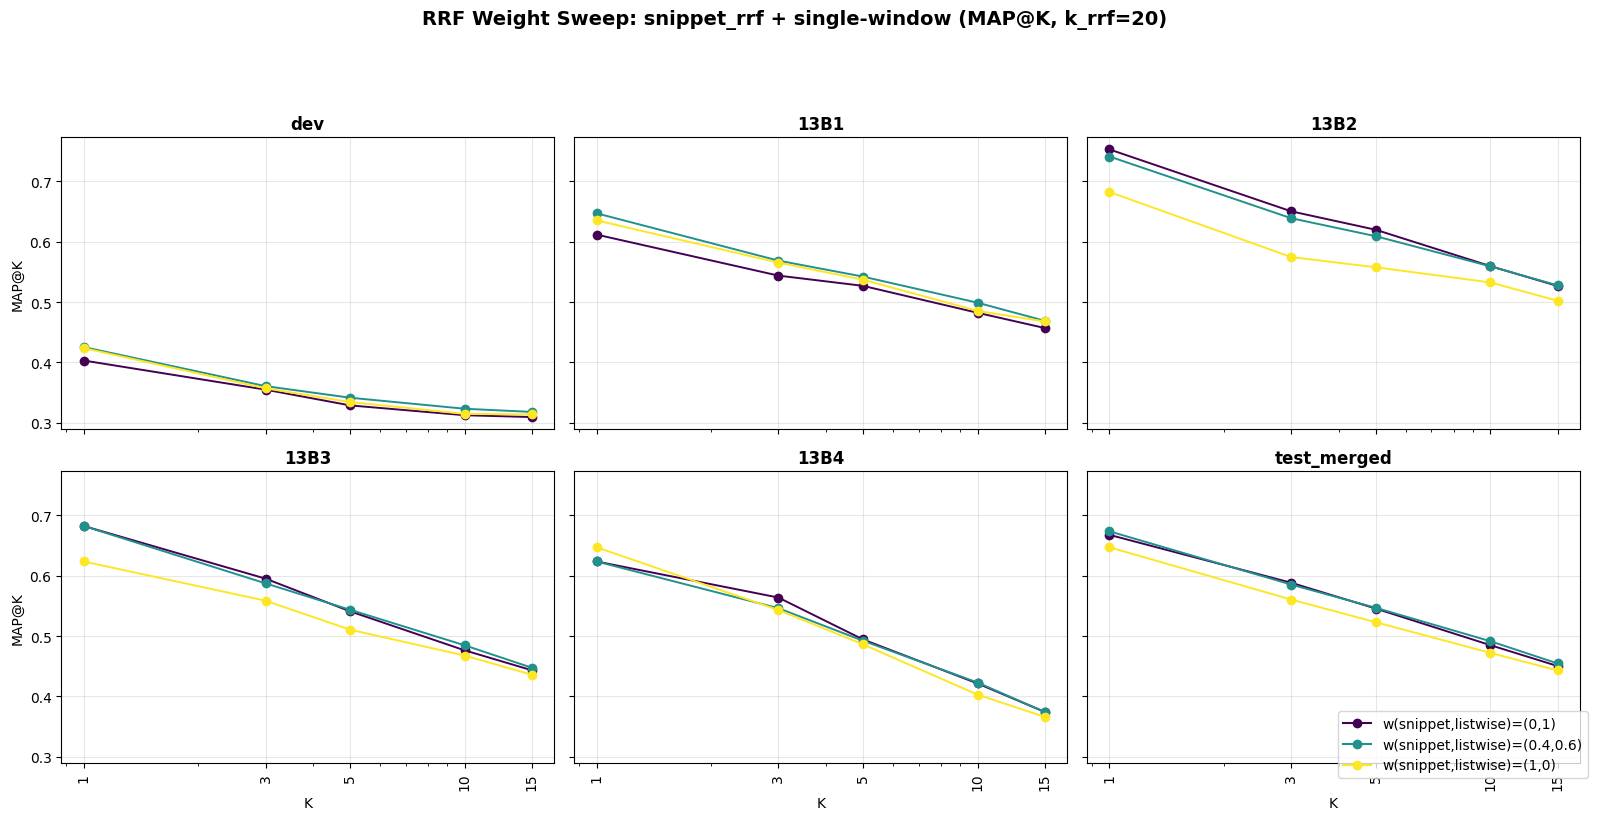

Saved MAP@K figure: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes_gemma/listwise_rerank/figures/rrf_sweep_snippet_plus_sliding_window_mapk.png


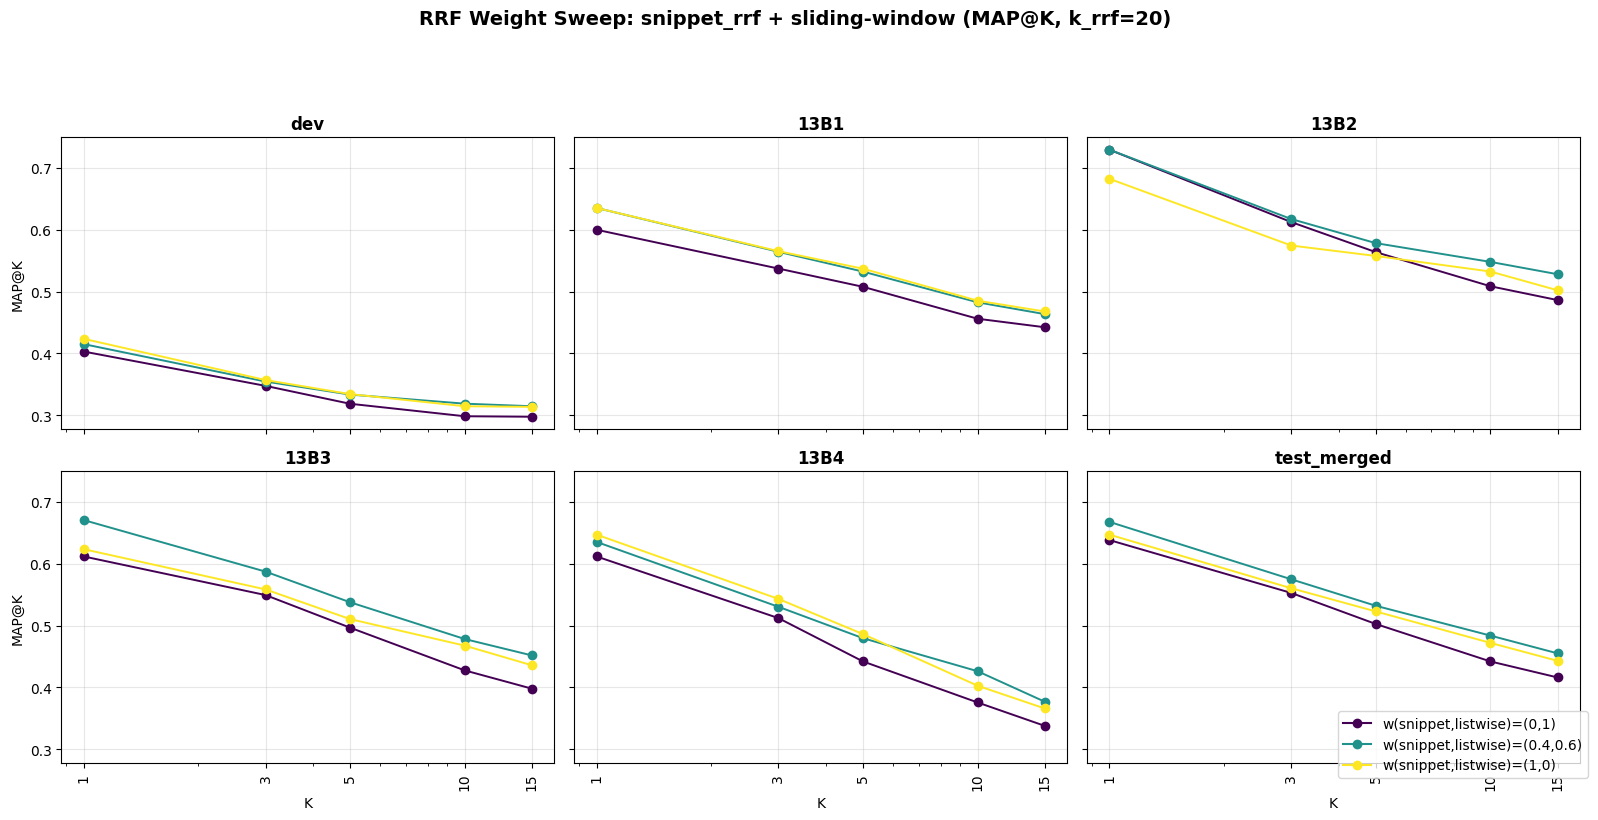

In [71]:
WEIGHT_PAIRS_MAPK = DEFAULT_WEIGHT_PAIRS

plot_rrf_sweep_curves("single-window", curves_single, weight_pairs=WEIGHT_PAIRS_MAPK)
plot_rrf_sweep_curves("sliding-window", curves_sliding, weight_pairs=WEIGHT_PAIRS_MAPK)

### 8.3 MAP@10 vs weight config (control weight config here)

`WEIGHT_PAIRS_MAP10` selects which weight pairs appear on the x-axis.
Set to `None` to show **all** weight pairs from the sweep data.
To show a subset, e.g.: `WEIGHT_PAIRS_MAP10 = [(0.0, 1.0), (0.5, 0.5), (1.0, 0.0)]`
The sweep data is produced by cell 8.1 — re-run 8.1 if you change
W_SNIPPET_GRID in the config cell above.

MAP@10 plot: 11 weight pairs available in sweep data
Saved MAP@10-vs-weight figure: /Users/yun/develop/BioASQ/output/workflow_baseline_full_run_both_routes_gemma/listwise_rerank/figures/rrf_sweep_map10_vs_weight_single_vs_sliding.png


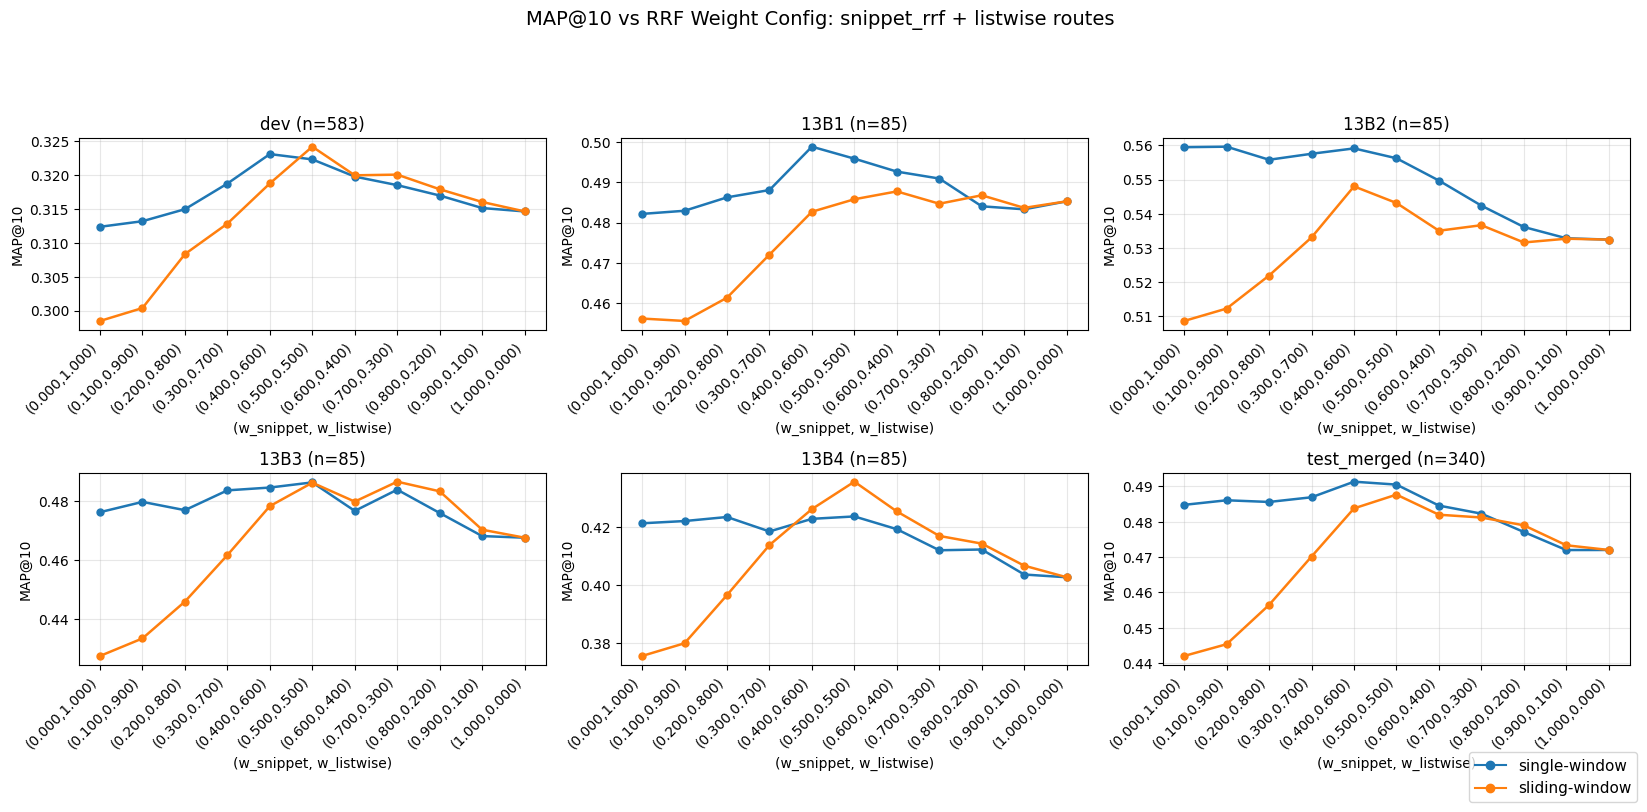

In [66]:
WEIGHT_PAIRS_MAP10 = None  # None = use all weight pairs from sweep data


def plot_map10_vs_weight_config(
    sweep_single_df: pd.DataFrame,
    sweep_sliding_df: pd.DataFrame,
    weight_pairs: list[tuple[float, float]] | None = None,
):
    """Line plot: MAP@10 vs weight config, one panel per split, one line per route.

    weight_pairs controls which weight points appear on the x-axis.
    If the sweep data doesn't contain a requested pair it is silently skipped.
    If weight_pairs is None, all weight pairs present in the sweep data are used.
    """
    single = sweep_single_df.copy()
    sliding = sweep_sliding_df.copy()
    if single.empty and sliding.empty:
        print("No sweep results available for MAP@10-vs-weight plot.")
        return

    if not single.empty:
        single["route"] = "single-window"
    if not sliding.empty:
        sliding["route"] = "sliding-window"
    combined = pd.concat([single, sliding], ignore_index=True)
    if combined.empty:
        print("Combined sweep table is empty.")
        return

    combined["weight_label"] = combined.apply(
        lambda r: _weight_label_compact(float(r["w_snippet"]), float(r["w_listwise"])),
        axis=1,
    )

    # Determine available weight labels from the sweep data itself.
    available = sorted(combined["weight_label"].unique())

    if weight_pairs is not None:
        requested = [_weight_label_compact(ws, wl) for ws, wl in weight_pairs]
        weight_order = [lbl for lbl in requested if lbl in set(available)]
    else:
        weight_order = available

    combined = combined[combined["weight_label"].isin(set(weight_order))]

    n_available = len(weight_order)
    print(f"MAP@10 plot: {n_available} weight pairs available in sweep data")
    if weight_pairs is not None and n_available < len(weight_pairs):
        print(
            f"  NOTE: sweep data has {n_available} of {len(weight_pairs)} "
            f"requested weights. Re-run cell 8.1 if you changed W_SNIPPET_GRID."
        )

    n_splits = len(SPLITS_SWEEP)
    n_cols = 3
    n_rows = (n_splits + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4 * n_rows), sharey=False)
    axes = np.array(axes).reshape(-1)

    route_colors = {
        "single-window": "#1f77b4",
        "sliding-window": "#ff7f0e",
    }

    for ax, split in zip(axes, SPLITS_SWEEP):
        grp = combined[combined["split"] == split]
        if grp.empty:
            ax.set_visible(False)
            continue

        for route in ["single-window", "sliding-window"]:
            sub = grp[grp["route"] == route]
            if sub.empty:
                continue
            ordered = sub.set_index("weight_label").reindex(weight_order)
            valid = ordered["MAP@10"].dropna()
            if valid.empty:
                continue
            x_pos = [weight_order.index(lbl) for lbl in valid.index]
            ax.plot(
                x_pos,
                valid.values,
                marker="o",
                linestyle="-",
                linewidth=1.8,
                markersize=5,
                color=route_colors[route],
                label=route,
            )

        n_q = int(grp["n_queries"].max()) if "n_queries" in grp.columns and len(grp) else 0
        ax.set_title(f"{SPLIT_LABELS_SWEEP.get(split, split)} (n={n_q})")
        ax.set_xticks(range(len(weight_order)))
        ax.set_xticklabels(weight_order, rotation=45, ha="right")
        ax.set_xlabel("(w_snippet, w_listwise)")
        ax.set_ylabel("MAP@10")
        ax.grid(True, alpha=0.3)

    for j in range(n_splits, len(axes)):
        axes[j].set_visible(False)

    legend_handles = [
        plt.Line2D([0], [0], color=route_colors[r], marker="o", linestyle="-", label=r)
        for r in ["single-window", "sliding-window"]
    ]
    fig.legend(
        handles=legend_handles,
        labels=[h.get_label() for h in legend_handles],
        loc="lower right",
        bbox_to_anchor=(1.0, 0.02),
        fontsize=11,
    )
    plt.suptitle("MAP@10 vs RRF Weight Config: snippet/snippet_doc_fusion + listwise routes", y=1.02, fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    out_png = SWEEP_OUT_DIR / "rrf_sweep_map10_vs_weight_single_vs_sliding.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print(f"Saved MAP@10-vs-weight figure: {out_png}")
    plt.show()


plot_map10_vs_weight_config(sweep_single, sweep_sliding, weight_pairs=WEIGHT_PAIRS_MAP10)